* Autor: Nunes, Claudio Rodrigues
* (x,Instagram, Youtube): @_claudionunes_
* github: https://github.com/ClaudioRodriguesNunes
* Idioma: Portugues/Portuguese

==========================================================================
1. Introdução e entendimento do problema
2. EDA
3. Baseline (sem tratamento aprofundado)
   3.1 Linear Regression
   3.2 Random Forest
   3.3 Comparação
4. Tratamento de Missing Values
   4.1 Estratégia adotada
   4.2 Nova preparação dos dados
   4.3 LR vs RF (pós-missing)
5. Tratamento de Outliers
   5.1 Identificação
   5.2 Decisão e justificativa
   5.3 LR vs RF (pós-outliers)
6. Discussão dos resultados
7. Próximos passos

* Tipo de problema: regressão supervisionada
* Target: SalePrice
* Features: 79 variáveis explicativas
* Local: Ames, Iowa (mercado imobiliário real)
* Objetivo: prever o preço final de venda
* Métrica oficial da competição: RMSE sobre o log do preço (log(SalePrice))

1. Introdução e entendimento do problema - CONCLUÍDO
2. EDA
3. Baseline (sem tratamento aprofundado)
   3.1 Linear Regression
   3.2 Random Forest
   3.3 Comparação
4. Tratamento de Missing Values
   4.1 Estratégia adotada
   4.2 Nova preparação dos dados
   4.3 LR vs RF (pós-missing)
5. Tratamento de Outliers
   5.1 Identificação
   5.2 Decisão e justificativa
   5.3 LR vs RF (pós-outliers)
6. Discussão dos resultados
7. Próximos passos

# 1. Imports

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import OneHotEncoder

from sklearn.model_selection import KFold, cross_val_score  #### RMSE sobre log(SalePrice)

from sklearn.linear_model import LinearRegression

from sklearn.ensemble import RandomForestRegressor


# 2. Carregamento dos dados

In [2]:
train = pd.read_csv("F:/Faculdade/kaggle/Preço de casas/train.csv")
test  = pd.read_csv("F:/Faculdade/kaggle/Preço de casas/test.csv")

# 3. Visão geral do dataset

In [3]:
train.shape
train.info()
train.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


# 4. Variável alvo (SalePrice)

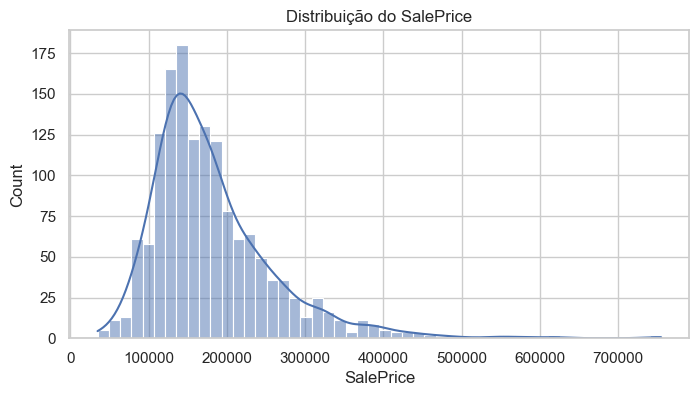

In [4]:
plt.figure(figsize=(8,4))
sns.histplot(train["SalePrice"], bins=50, kde=True)
plt.title("Distribuição do SalePrice")
plt.show()

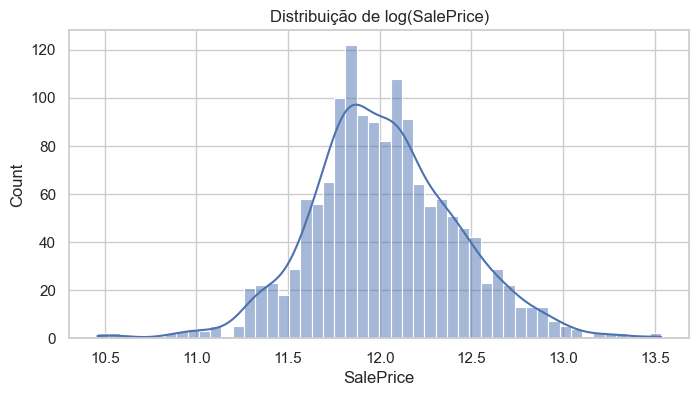

In [5]:
plt.figure(figsize=(8,4))
sns.histplot(np.log1p(train["SalePrice"]), bins=50, kde=True)
plt.title("Distribuição de log(SalePrice)")
plt.show()

# 5. Variáveis numéricas

In [6]:
numeric_features = train.select_dtypes(include=[np.number])
numeric_features.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


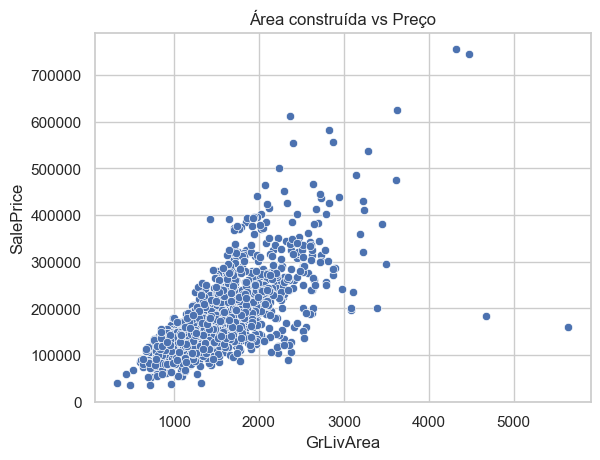

In [7]:
sns.scatterplot(x=train["GrLivArea"], y=train["SalePrice"])
plt.title("Área construída vs Preço")
plt.show()

# 6. Variáveis categóricas

In [8]:
categorical_features = train.select_dtypes(include=["object"])
categorical_features.nunique().sort_values(ascending=False)

Neighborhood     25
Exterior2nd      16
Exterior1st      15
Condition1        9
SaleType          9
HouseStyle        8
RoofMatl          8
Condition2        8
Functional        7
BsmtFinType2      6
RoofStyle         6
BsmtFinType1      6
SaleCondition     6
Heating           6
Foundation        6
GarageType        6
ExterCond         5
LotConfig         5
MSZoning          5
GarageCond        5
GarageQual        5
HeatingQC         5
Electrical        5
BldgType          5
FireplaceQu       5
LandContour       4
LotShape          4
KitchenQual       4
MiscFeature       4
Fence             4
BsmtCond          4
ExterQual         4
BsmtExposure      4
BsmtQual          4
LandSlope         3
PoolQC            3
GarageFinish      3
PavedDrive        3
MasVnrType        3
Utilities         2
Alley             2
Street            2
CentralAir        2
dtype: int64

# 7. Missing values

In [9]:
missing = train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing.head(15)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
dtype: int64

## Observações iniciais:
#### - SalePrice é fortemente assimétrico à direita
#### - log(SalePrice) aproxima distribuição normal
#### - Existem muitas variáveis categóricas
#### - Missing values parecem estruturais (não aleatórios)
#### - Algumas variáveis numéricas possuem outliers claros

1. Introdução e entendimento do problema - CONCLUÍDA
2. EDA - CONCLUÍDA
3. Baseline (sem tratamento aprofundado)
   3.1 Linear Regression
   3.2 Random Forest
   3.3 Comparação
4. Tratamento de Missing Values
   4.1 Estratégia adotada
   4.2 Nova preparação dos dados
   4.3 LR vs RF (pós-missing)
5. Tratamento de Outliers
   5.1 Identificação
   5.2 Decisão e justificativa
   5.3 LR vs RF (pós-outliers)
6. Discussão dos resultados
7. Próximos passos

In [10]:
y = train["SalePrice"]
X = train.drop(columns=["SalePrice"])

y_log = np.log1p(y)

In [11]:
categorical_cols = X.select_dtypes(include="object").columns
numeric_cols = X.select_dtypes(exclude="object").columns

### Tratar os missing estruturais

Aqui eu considerei somente em substituir os missing valores nas colunas que a falta de valores tinha signfiicado.  Não fiz nenhuma apuração mais aprofundada neste momento.

### 1 - Lista inicial

Acessei o arquivo dicionário fornecido pelo desafio e identifiquei manualmente uma lista de colunas que o vazio tinha significado.

In [12]:
na_as_none_cols = [
    "Alley", "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1",
    "FireplaceQu", "GarageType", "GarageFinish", "GarageQual",
    "GarageCond", "PoolQC", "Fence", "MiscFeature"
]

#### Processando preenchimento explícito

In [13]:
for col in na_as_none_cols:
    X[col] = X[col].fillna("None")

### Tratar missing reais

Em relação os missing reais, não usei nenhuma avaliação profunda e nem critério aperfeiçoado para tratar esses missing.  Usei basicamente Mediana e Moda.

### 1 - Mediana

In [14]:
num_imputer = SimpleImputer(strategy="median")
X[numeric_cols] = num_imputer.fit_transform(X[numeric_cols])

### 2 - Moda

In [15]:
cat_imputer = SimpleImputer(strategy="most_frequent")
X[categorical_cols] = cat_imputer.fit_transform(X[categorical_cols])

### Encoding das categóricas

In [16]:
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

X_encoded = encoder.fit_transform(X[categorical_cols])


### Juntar tudo

In [17]:
X_encoded_df = pd.DataFrame(
    X_encoded,
    columns=encoder.get_feature_names_out(categorical_cols),
    index=X.index
)

X_final = pd.concat(
    [X[numeric_cols], X_encoded_df],
    axis=1
)


In [18]:
X_final.shape
X_final.isnull().sum().sum()


np.int64(0)

1. Introdução e entendimento do problema - CONCLUÍDO
2. EDA - CONCLUÍDO
3. Baseline (sem tratamento aprofundado) - CONCLUÍDO
   3.1 Linear Regression
   3.2 Random Forest
   3.3 Comparação
4. Tratamento de Missing Values
   4.1 Estratégia adotada
   4.2 Nova preparação dos dados
   4.3 LR vs RF (pós-missing)
5. Tratamento de Outliers
   5.1 Identificação
   5.2 Decisão e justificativa
   5.3 LR vs RF (pós-outliers)
6. Discussão dos resultados
7. Próximos passos

### Validação Local e Treino dos Modelos

### 1 - Objetivo:
#### Comparar Linear Regression vs RandomForest usando a mesma base preparada, a mesma métrica e a mesma validação.

### a) Definir validação cruzada (K-Fold)

In [19]:
kf = KFold(
    n_splits=5,
    shuffle=True, #### evita viés de ordenação
    random_state=42
)

### b) Modelo 1 — Linear Regression

In [20]:
lin_reg = LinearRegression()

scores_lr = cross_val_score(
    lin_reg,
    X_final,
    y_log,
    cv=kf,
    scoring="neg_root_mean_squared_error"
)

rmse_lr = -scores_lr.mean()
rmse_lr  #### “Quanto um modelo simples consegue aprender desses dados?”

np.float64(0.15102425583925955)

### c) Modelo 2 — RandomForest

In [21]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

scores_rf = cross_val_score(
    rf,
    X_final,
    y_log,
    cv=kf,
    scoring="neg_root_mean_squared_error"
)

rmse_rf = -scores_rf.mean()
rmse_rf


np.float64(0.1450515545734936)

### d) Comparação objetiva

In [22]:
print(f"Linear Regression RMSE (log): {rmse_lr:.4f}")
print(f"Random Forest RMSE (log): {rmse_rf:.4f}")

Linear Regression RMSE (log): 0.1510
Random Forest RMSE (log): 0.1451


1. Introdução e entendimento do problema - CONCLUÍDO
2. EDA -  CONCLUÍDO
3. Baseline (sem tratamento aprofundado) - CONCLUÍDO
   3.1 Linear Regression - CONCLUÍDO
   3.2 Random Forest - CONCLUÍDO
   3.3 Comparação - CONCLUÍDO
4. Tratamento de Missing Values
   4.1 Estratégia adotada
   4.2 Nova preparação dos dados
   4.3 LR vs RF (pós-missing)
5. Tratamento de Outliers
   5.1 Identificação
   5.2 Decisão e justificativa
   5.3 LR vs RF (pós-outliers)
6. Discussão dos resultados
7. Próximos passos

4. Tratamento de Missing Values

Iniciei um tratamento mais profundo de missing values, partindo com o banco original, para evitar vazamento.  Para tanto, busquei fazer uma nova EDA mais minucioso.

In [23]:
train_raw = pd.read_csv("F:/Faculdade/kaggle/Preço de casas/train.csv")

a) Identificar colunas com missing (bruto)

In [24]:
missing_counts = train_raw.isnull().sum()
missing_cols = missing_counts[missing_counts > 0].sort_values(ascending=False)
missing_cols


PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

b) Separar variáveis categóricas e numéricas (com missing)

In [25]:
missing_df = missing_cols.reset_index()
missing_df.columns = ["column", "missing_count"]

missing_df["dtype"] = missing_df["column"].apply(
    lambda c: train_raw[c].dtype
)

missing_df

,column,missing_count,dtype
0,PoolQC,1453,object
1,MiscFeature,1406,object
2,Alley,1369,object
3,Fence,1179,object
4,MasVnrType,872,object
5,FireplaceQu,690,object
6,LotFrontage,259,float64
7,GarageType,81,object
8,GarageYrBlt,81,float64
9,GarageFinish,81,object


In [26]:
missing_cat = missing_df[missing_df["dtype"] == "object"]
missing_num = missing_df[missing_df["dtype"] != "object"]

c) TABELA — Missing em variáveis categóricas (reais)

In [27]:
missing_cat.sort_values("missing_count", ascending=False)

,column,missing_count,dtype
0,PoolQC,1453,object
1,MiscFeature,1406,object
2,Alley,1369,object
3,Fence,1179,object
4,MasVnrType,872,object
5,FireplaceQu,690,object
7,GarageType,81,object
9,GarageFinish,81,object
10,GarageQual,81,object
11,GarageCond,81,object


d) GRÁFICO DE BARRAS — Missing categóricos

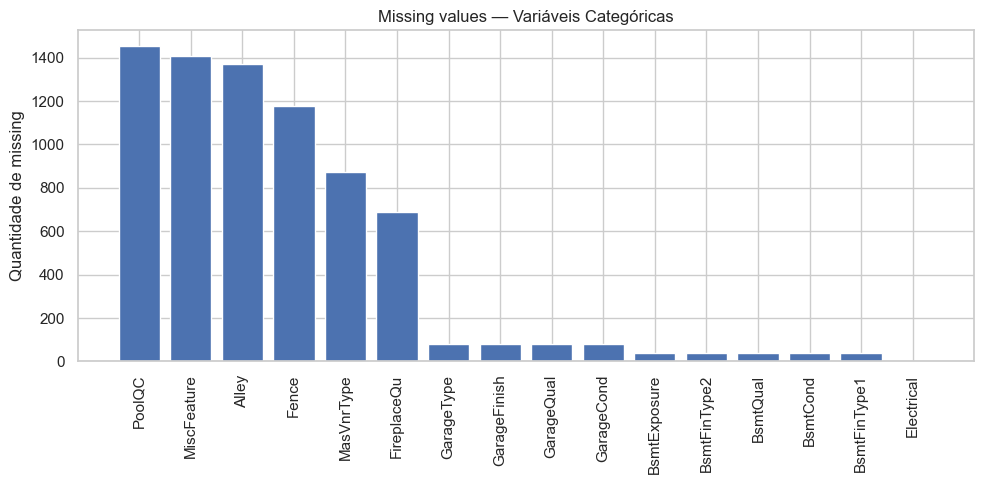

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.bar(
    missing_cat["column"],
    missing_cat["missing_count"]
)
plt.xticks(rotation=90)
plt.title("Missing values — Variáveis Categóricas")
plt.ylabel("Quantidade de missing")
plt.tight_layout()
plt.show()

e) TABELA — Missing em variáveis numéricas

In [29]:
missing_num.sort_values("missing_count", ascending=False)

,column,missing_count,dtype
6,LotFrontage,259,float64
8,GarageYrBlt,81,float64
17,MasVnrArea,8,float64


f) GRÁFICO DE BARRAS — Missing numéricos

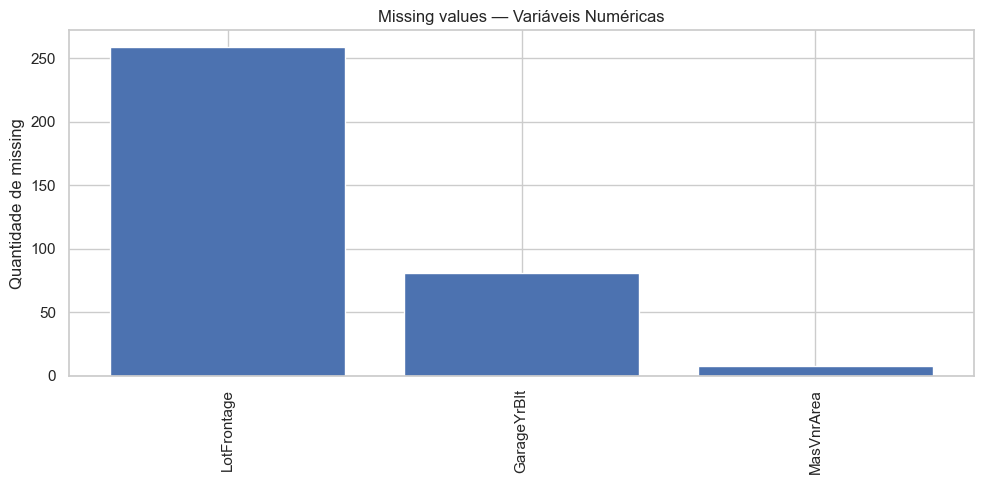

In [30]:
plt.figure(figsize=(10, 5))
plt.bar(
    missing_num["column"],
    missing_num["missing_count"]
)
plt.xticks(rotation=90)
plt.title("Missing values — Variáveis Numéricas")
plt.ylabel("Quantidade de missing")
plt.tight_layout()
plt.show()

4.1 Estratégia adotada

Analisei em blocos de dados distintos: Porão (Bsmt), Piscina (Pool), Lareira (FirePlace), Garagem (Garage) e Misc.

a) EDA - Bloco 1 - Basement

* Caso A — Área zero, mas categorias preenchidas

In [31]:
bsmt_cols_cat = [
    "BsmtQual", "BsmtCond", "BsmtExposure",
    "BsmtFinType1", "BsmtFinType2"
]

bsmt_inconsist_cat = train_raw[
    (train_raw["TotalBsmtSF"] == 0) &
    (train_raw[bsmt_cols_cat].notna().any(axis=1))
]

bsmt_inconsist_cat.shape[0]

0

* Caso B — Área positiva, mas categorias ausentes

In [32]:
bsmt_inconsist_missing = train_raw[
    (train_raw["TotalBsmtSF"] > 0) &
    (train_raw["BsmtQual"].isna())
]

bsmt_inconsist_missing.shape[0]

0

* Tabela — distribuição de TotalBsmtSF

In [33]:
train_raw["TotalBsmtSF"].describe()

count    1460.000000
mean     1057.429452
std       438.705324
min         0.000000
25%       795.750000
50%       991.500000
75%      1298.250000
max      6110.000000
Name: TotalBsmtSF, dtype: float64

* Presença de Porão

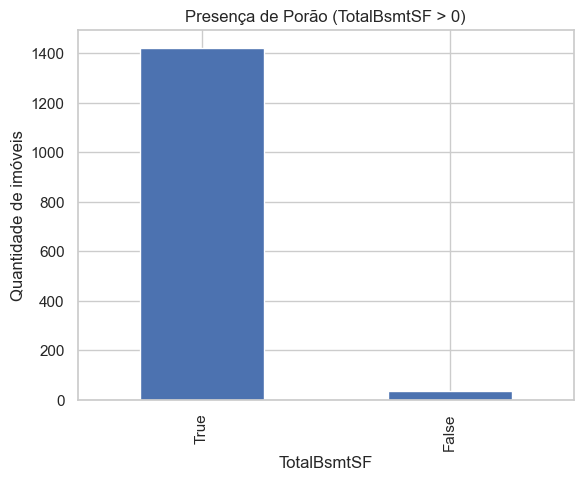

In [34]:
(train_raw["TotalBsmtSF"] > 0).value_counts().plot(
    kind="bar",
    title="Presença de Porão (TotalBsmtSF > 0)"
)
plt.ylabel("Quantidade de imóveis")
plt.show()

b) EDA - Bloco 2 - Garage

* Inconsistências — carros vs tipo

In [35]:
garage_cat_cols = [
    "GarageType", "GarageFinish", "GarageQual", "GarageCond"
]

garage_inconsist_cat = train_raw[
    (train_raw["GarageCars"] == 0) &
    (train_raw[garage_cat_cols].notna().any(axis=1))
]

garage_inconsist_cat.shape[0]


0

* Área/capacidade incompatíveis

In [36]:
garage_inconsist_area = train_raw[
    (train_raw["GarageCars"] > 0) &
    (train_raw["GarageArea"] == 0)
]

garage_inconsist_area.shape[0]

0

* Gráfico — distribuição de GarageCars

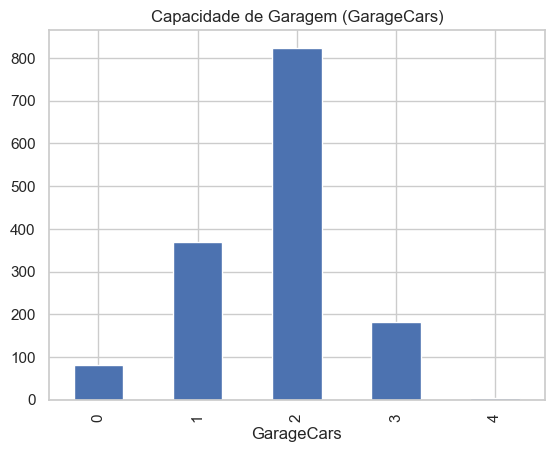

In [37]:
train_raw["GarageCars"].value_counts().sort_index().plot(
    kind="bar",
    title="Capacidade de Garagem (GarageCars)"
)
plt.show()

In [38]:
train_raw["GarageArea"].describe()

count    1460.000000
mean      472.980137
std       213.804841
min         0.000000
25%       334.500000
50%       480.000000
75%       576.000000
max      1418.000000
Name: GarageArea, dtype: float64

c) EDA - Bloco 3 - FirePlace

* Inconsistência

In [39]:
fireplace_inconsist = train_raw[
    ((train_raw["Fireplaces"] == 0) & train_raw["FireplaceQu"].notna()) |
    ((train_raw["Fireplaces"] > 0) & train_raw["FireplaceQu"].isna())
]

fireplace_inconsist.shape[0]

0

d) EDA - Bloco 4 - Pool

In [40]:
pool_inconsist = train_raw[
    ((train_raw["PoolArea"] == 0) & train_raw["PoolQC"].notna()) |
    ((train_raw["PoolArea"] > 0) & train_raw["PoolQC"].isna())
]

pool_inconsist.shape[0]

0

e) EDA - Bloco 5 - Misc

In [41]:
misc_inconsist = train_raw[
    ((train_raw["MiscVal"] == 0) & train_raw["MiscFeature"].notna()) |
    ((train_raw["MiscVal"] > 0) & train_raw["MiscFeature"].isna())
]

misc_inconsist.shape[0]

2

f) Análise de Consistência Estrutural entre Variáveis Relacionadas (EDA HARD)

Com o objetivo de realizar um tratamento aprofundado e conceitualmente correto dos *missing values*, foi conduzida uma análise detalhada de consistência entre grupos de variáveis semanticamente relacionadas. Essa etapa foi realizada **antes de qualquer imputação**, utilizando o conjunto de dados original, de modo a evitar vazamento de informação (*data leakage*).

A análise concentrou-se em verificar se a ausência ou presença de determinadas estruturas físicas (porão, garagem, lareira, piscina etc.) estava coerente entre variáveis categóricas e numéricas associadas.

### Piscina (Pool)

* **Variáveis analisadas**:
  `PoolArea` (área da piscina)
  `PoolQC` (qualidade da piscina)

**Resultado:**
Não foram identificadas inconsistências nem valores considerados estranhos.
Os registros indicam que:

* Imóveis sem piscina apresentam `PoolArea = 0` e `PoolQC` ausente.
* Imóveis com piscina apresentam `PoolArea > 0` e `PoolQC` devidamente preenchido.

Conclusão: os dados referentes à piscina apresentam **consistência estrutural plena**.

---

### Recursos Extras (Miscellaneous)

* **Variáveis analisadas**:
  `MiscFeature` (recurso extra)
  `MiscVal` (valor do recurso extra)

**Resultado:**
Foram identificadas **duas inconsistências pontuais**, envolvendo discrepâncias entre a presença de valor monetário (`MiscVal`) e a indicação do tipo de recurso (`MiscFeature`).

Conclusão: embora raras, essas inconsistências justificam tratamento específico e localizado em etapa posterior.

---

### Rua / Viela de Serviço (Alley)

* **Variável analisada**:
  `Alley` (tipo de acesso por viela ou rua de serviço)

**Resultado:**
A ausência de valor em `Alley` representa corretamente a inexistência de acesso por viela, não configurando *missing value* informacional, mas sim **ausência estrutural**.

Conclusão: a variável está semanticamente coerente com o dicionário de dados.

---

### Porão (Basement)

* **Variáveis analisadas**:
  `BsmtQual`, `BsmtCond`, `BsmtExposure`,
  `BsmtFinType1`, `BsmtFinSF1`,
  `BsmtFinType2`, `BsmtFinSF2`,
  `BsmtUnfSF`, `TotalBsmtSF`

**Perguntas investigadas e respostas:**

* Quantos imóveis não têm porão, mas possuem alguma informação de porão preenchida?
  **Nenhum.**

* Quantos imóveis possuem porão (`TotalBsmtSF > 0`) mas não informaram qualidade (`BsmtQual`)?
  **Nenhum.**

* As inconsistências são frequentes ou raras?
  **Inexistentes.**

* Há indícios de erro de coleta ou padrão histórico inadequado?
  **Não.**

* Existem casos estranhos de porões extremamente pequenos?
  Não foram observadas anomalias evidentes a partir da análise estatística descritiva. Para uma investigação mais fina, análises adicionais (como moda ou inspeção de valores mínimos positivos) poderiam ser conduzidas, mas não há indícios imediatos de problemas.

Conclusão: o conjunto de variáveis relacionadas ao porão apresenta **alta consistência estrutural**.

---

### Lareira (FirePlace)

* **Variáveis analisadas**:
  `Fireplaces` (número de lareiras)
  `FireplaceQu` (qualidade da lareira)

**Resultado:**
Não foram encontradas inconsistências nem valores estranhos.
Os dados indicam coerência entre a existência de lareiras e o preenchimento da variável de qualidade.

Conclusão: dados consistentes.

---

### Garagem (Garage)

* **Variáveis analisadas**:
  `GarageType`, `GarageYrBlt`, `GarageFinish`,
  `GarageCars`, `GarageArea`,
  `GarageQual`, `GarageCond`

**Resultado:**
Não foram identificadas inconsistências estruturais:

* Imóveis sem garagem apresentam `GarageCars = 0` e `GarageArea = 0`, com variáveis categóricas ausentes.
* Imóveis com garagem apresentam informações coerentes de tipo, área e capacidade.

A análise estatística descritiva de `GarageArea` não indicou valores anômalos.

Conclusão: o bloco de variáveis de garagem é **estruturalmente consistente**.

---

### Cerca (Fence)

* **Variável analisada**:
  `Fence` (qualidade da cerca)

**Resultado:**
A ausência de valor indica corretamente a inexistência de cerca, caracterizando ausência estrutural e não erro de preenchimento.

Conclusão: variável consistente com o dicionário de dados.

---

### Síntese Geral

De forma geral, a análise de consistência estrutural mostrou que:

* A maioria dos *missing values* é **estrutural**, não aleatória.
* As inconsistências são **raras** e concentradas em poucos registros.
* O dataset apresenta **alta qualidade de coerência interna**, o que permite avançar para a próxima etapa com segurança.


4.2 Tratamento de Missing Values

A partir da análise de consistência estrutural realizada na etapa de EDA HARD, verificou-se que os valores ausentes presentes no conjunto de dados não caracterizam missing values informacionais, mas sim ausências estruturais, conforme definido no dicionário de dados.

As variáveis associadas a porão, garagem, piscina, lareira, cerca, viela de serviço e recursos extras apresentaram coerência interna entre variáveis categóricas e numéricas relacionadas, não sendo observadas inconsistências relevantes ou padrões que justificassem imputação ou transformação adicional.

Dessa forma, não foi aplicado tratamento adicional de missing values nesta etapa, preservando-se a estrutura original dos dados.

4.3 Comparação dos Modelos após Análise de Missing Values

Como a análise aprofundada de missing values não resultou em modificações no conjunto de dados — uma vez que as ausências observadas são de natureza estrutural —, a base utilizada nesta etapa permanece idêntica àquela empregada no experimento de baseline.

Consequentemente, os resultados da comparação entre Linear Regression e Random Forest permanecem inalterados em relação ao Item 3.3, não sendo necessária a reexecução do procedimento de validação cruzada.

1. Introdução e entendimento do problema - CONCLUÍDO
2. EDA -  CONCLUÍDO
3. Baseline (sem tratamento aprofundado) - CONCLUÍDO
   3.1 Linear Regression - CONCLUÍDO
   3.2 Random Forest - CONCLUÍDO
   3.3 Comparação - CONCLUÍDO
4. Tratamento de Missing Values - CONCLUÍDO
   4.1 Estratégia adotada - CONCLUÍDO
   4.2 Nova preparação dos dados - CONCLUÍDO
   4.3 LR vs RF (pós-missing) - CONCLUÍDO
5. Tratamento de Outliers
   5.1 Identificação
   5.2 Decisão e justificativa
   5.3 LR vs RF (pós-outliers)
6. Discussão dos resultados
7. Próximos passos

5. Tratamento de Outliers

Na EDA inicial já foi identificado alguns outliers, porém não foi tratado.  A partir de agora vamos aprofundar na identificação, avaliar se vale a pena tratar, como tratar, tratar e aplicar as técnicas LR e RF e fazer as comparações.

5.1 Identificação

a) Começar pelo alvo: SalePrice

In [42]:
train_raw["SalePrice"].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

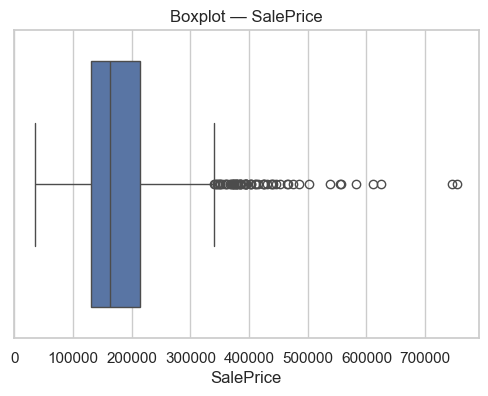

In [43]:
plt.figure(figsize=(6,4))
sns.boxplot(x=train_raw["SalePrice"])
plt.title("Boxplot — SalePrice")
plt.show()


b) Variáveis numéricas mais críticas

* GrLivArea × SalePrice

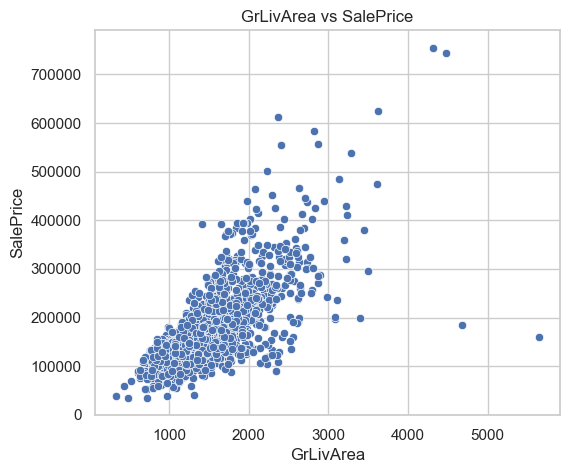

In [44]:
plt.figure(figsize=(6,5))
sns.scatterplot(
    x=train_raw["GrLivArea"],
    y=train_raw["SalePrice"]
)
plt.title("GrLivArea vs SalePrice")
plt.show()


* TotalBsmtSF × SalePrice

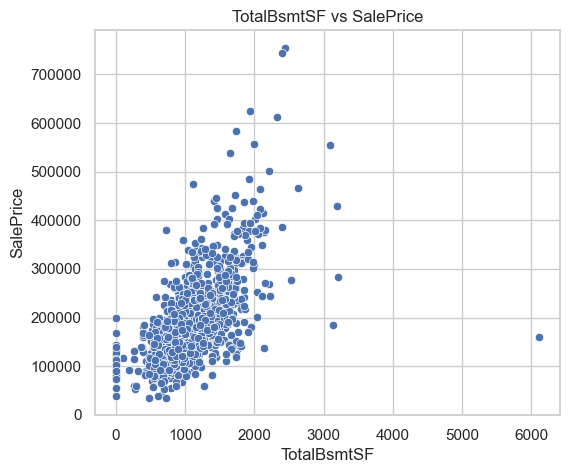

In [45]:
plt.figure(figsize=(6,5))
sns.scatterplot(
    x=train_raw["TotalBsmtSF"],
    y=train_raw["SalePrice"]
)
plt.title("TotalBsmtSF vs SalePrice")
plt.show()


* GarageArea × SalePrice

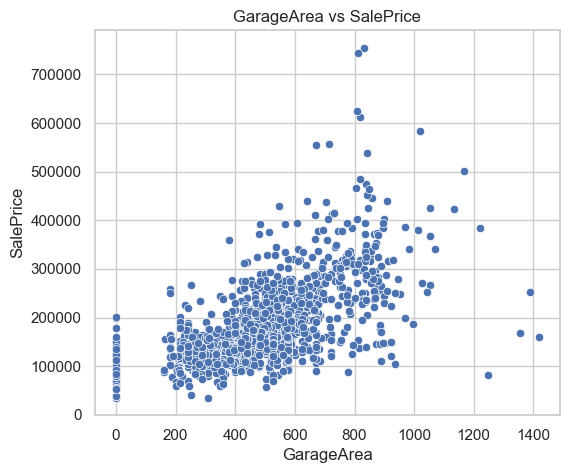

In [46]:
plt.figure(figsize=(6,5))
sns.scatterplot(
    x=train_raw["GarageArea"],
    y=train_raw["SalePrice"]
)
plt.title("GarageArea vs SalePrice")
plt.show()

* LotArea × SalePrice

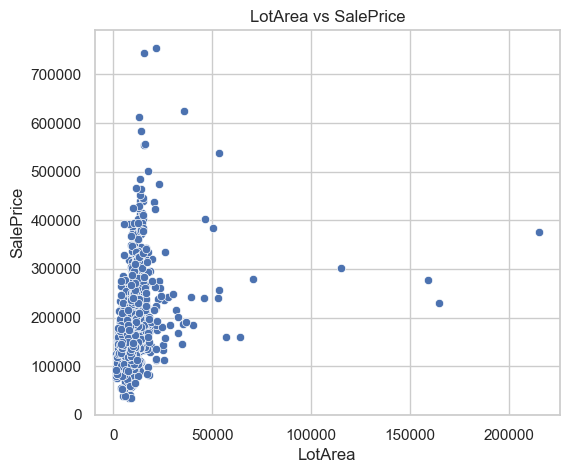

In [47]:
plt.figure(figsize=(6,5))
sns.scatterplot(
    x=train_raw["LotArea"],
    y=train_raw["SalePrice"]
)
plt.title("LotArea vs SalePrice")
plt.show()

c) Detecção objetiva (sem decidir ainda)

* GrLivArea

In [48]:
Q1 = train_raw["GrLivArea"].quantile(0.25)
Q3 = train_raw["GrLivArea"].quantile(0.75)
IQR = Q3 - Q1

outliers_grliv = train_raw[
    train_raw["GrLivArea"] > Q3 + 1.5 * IQR
]

outliers_grliv.shape[0]

31

São 31 outliers.

* TotalBsmtSF

In [49]:
Q1 = train_raw["TotalBsmtSF"].quantile(0.25)
Q3 = train_raw["TotalBsmtSF"].quantile(0.75)
IQR = Q3 - Q1

outliers_TotalBsmtSF = train_raw[
    train_raw["TotalBsmtSF"] > Q3 + 1.5 * IQR
]

outliers_TotalBsmtSF.shape[0]

24

* GarageArea

In [50]:
Q1 = train_raw["GarageArea"].quantile(0.25)
Q3 = train_raw["GarageArea"].quantile(0.75)
IQR = Q3 - Q1

outliers_GarageArea = train_raw[
    train_raw["GarageArea"] > Q3 + 1.5 * IQR
]

outliers_GarageArea.shape[0]

21

* LotArea

In [51]:
Q1 = train_raw["LotArea"].quantile(0.25)
Q3 = train_raw["LotArea"].quantile(0.75)
IQR = Q3 - Q1

outliers_LotArea = train_raw[
    train_raw["LotArea"] > Q3 + 1.5 * IQR
]

outliers_LotArea.shape[0]

67

1. Introdução e entendimento do problema - CONCLUÍDO
2. EDA -  CONCLUÍDO
3. Baseline (sem tratamento aprofundado) - CONCLUÍDO
   3.1 Linear Regression - CONCLUÍDO
   3.2 Random Forest - CONCLUÍDO
   3.3 Comparação - CONCLUÍDO
4. Tratamento de Missing Values - CONCLUÍDO
   4.1 Estratégia adotada - CONCLUÍDO
   4.2 Nova preparação dos dados - CONCLUÍDO
   4.3 LR vs RF (pós-missing) - CONCLUÍDO
5. Tratamento de Outliers
   5.1 Identificação  - CONCLUÍDO
   5.2 Decisão e justificativa
   5.3 LR vs RF (pós-outliers)
6. Discussão dos resultados
7. Próximos passos

5.2 Decisão e Justificativa

Concluo que GrLivArea é onde deve ser tratado o outliers, pois há outliers que não segue a tendencia, conforme foi detectado nos gráficos.

a) INSPEÇÃO QUALITATIVA DOS OUTLIERS DE GrLivArea

In [52]:
Q1 = train_raw["GrLivArea"].quantile(0.25)
Q3 = train_raw["GrLivArea"].quantile(0.75)
IQR = Q3 - Q1

grliv_outliers = train_raw[
    train_raw["GrLivArea"] > Q3 + 1.5 * IQR
]

In [53]:
grliv_outliers.shape

(31, 81)

b) Tabela

In [54]:
cols_inspecao = [
    "Id",
    "SalePrice",
    "GrLivArea",
    "OverallQual",
    "OverallCond",
    "Neighborhood",
    "YearBuilt",
    "TotalBsmtSF",
    "GarageCars",
    "GarageArea",
    "TotRmsAbvGrd"
]

grliv_outliers[cols_inspecao].sort_values(
    by="GrLivArea",
    ascending=False
)


,Id,SalePrice,GrLivArea,OverallQual,OverallCond,Neighborhood,YearBuilt,TotalBsmtSF,GarageCars,GarageArea,TotRmsAbvGrd
1298,1299,160000,5642,10,5,Edwards,2008,6110,2,1418,12
523,524,184750,4676,10,5,Edwards,2007,3138,3,884,11
1182,1183,745000,4476,10,5,NoRidge,1996,2396,3,813,10
691,692,755000,4316,10,6,NoRidge,1994,2444,3,832,10
1169,1170,625000,3627,10,5,NoRidge,1995,1930,3,807,10
185,186,475000,3608,10,9,OldTown,1892,1107,3,840,12
304,305,295000,3493,7,9,OldTown,1880,1470,3,870,10
1268,1269,381000,3447,8,9,Crawfor,1935,728,3,1014,11
635,636,200000,3395,6,7,SWISU,1914,1440,0,0,14
769,770,538000,3279,8,5,StoneBr,2003,1650,3,841,12


c) Acrescentar “preço relativo” (insight poderoso)

In [55]:
grliv_outliers["Price_per_SF"] = (
    grliv_outliers["SalePrice"] / grliv_outliers["GrLivArea"]
)

grliv_outliers[cols_inspecao + ["Price_per_SF"]].sort_values(
    by="Price_per_SF"
)


C:\Users\webma\AppData\Local\Temp\ipykernel_2176\907651479.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  grliv_outliers["Price_per_SF"] = (


,Id,SalePrice,GrLivArea,OverallQual,OverallCond,Neighborhood,YearBuilt,TotalBsmtSF,GarageCars,GarageArea,TotRmsAbvGrd,Price_per_SF
1298,1299,160000,5642,10,5,Edwards,2008,6110,2,1418,12,28.358738
523,524,184750,4676,10,5,Edwards,2007,3138,3,884,11,39.510265
635,636,200000,3395,6,7,SWISU,1914,1440,0,0,14,58.910162
1031,1032,197000,3082,7,3,SWISU,1920,824,2,672,12,63.919533
1173,1174,200500,3086,5,6,ClearCr,1946,1598,0,0,12,64.970836
197,198,235000,3112,8,4,NAmes,1918,1360,2,795,8,75.514139
324,325,242000,2978,7,7,NAmes,1967,710,2,564,11,81.262592
304,305,295000,3493,7,9,OldTown,1880,1470,3,870,10,84.454624
1386,1387,250000,2784,7,5,NWAmes,1978,1392,2,564,12,89.798851
1328,1329,256000,2792,6,7,OldTown,1920,1510,2,520,8,91.690544


d) Comparação com imóveis “normais”

In [56]:
grliv_normais = train_raw[
    (train_raw["GrLivArea"] > train_raw["GrLivArea"].median()) &
    (train_raw["GrLivArea"] < Q3)
]

grliv_normais[cols_inspecao].sample(5, random_state=42)

,Id,SalePrice,GrLivArea,OverallQual,OverallCond,Neighborhood,YearBuilt,TotalBsmtSF,GarageCars,GarageArea,TotRmsAbvGrd
781,782,175900,1603,6,5,SawyerW,1992,761,2,484,7
139,140,231500,1764,6,5,CollgCr,1997,928,2,470,7
63,64,140000,1710,7,6,OldTown,1921,576,2,480,9
1382,1383,157000,1762,7,7,OldTown,1920,596,2,576,8
237,238,194500,1744,7,7,SawyerW,1993,996,2,457,7


e) Avaliação

A inspeção qualitativa dos outliers identificados na variável GrLivArea mostrou que esses registros correspondem, em sua maioria, a imóveis de alto padrão, caracterizados por grande área construída, elevado número de cômodos, boa qualidade construtiva e garagens compatíveis com o porte das residências.

Dos 31 registros classificados inicialmente como outliers pelo critério estatístico (IQR), apenas dois apresentaram preço por área significativamente inferior ao restante do conjunto. Ainda assim, esses casos não se mostraram suficientemente discrepantes a ponto de caracterizar erro evidente ou distorção estrutural do fenômeno analisado.

Diante disso, conclui-se que não há justificativa técnica para a aplicação de tratamento global ou pontual de outliers nesta variável, optando-se por manter os dados originais a fim de preservar a variabilidade real do mercado imobiliário representado no dataset.

5.3 LR vs RF (pós-outliers)

Considerando que a análise aprofundada dos outliers não resultou em modificações no conjunto de dados — uma vez que os registros extremos representam casos reais e coerentes com o fenômeno estudado —, a base utilizada permanece idêntica àquela empregada na etapa de baseline.

Assim, não se fez necessária a reexecução da comparação entre os modelos Linear Regression e Random Forest, visto que não houve alteração nos dados que pudesse impactar os resultados anteriormente obtidos.

6. Discussão dos resultados

A análise conduzida ao longo deste estudo permitiu compreender que os valores ausentes presentes no conjunto de dados correspondem, majoritariamente, a ausências estruturais — e não a falhas no processo de coleta — conforme evidenciado pela coerência entre variáveis categóricas e numéricas relacionadas.

De forma análoga, a investigação detalhada dos outliers revelou que esses registros representam, em sua maioria, imóveis de alto padrão, não configurando erros ou inconsistências capazes de comprometer o desempenho dos modelos.

A comparação inicial entre os modelos de Regressão Linear e Random Forest já indicava diferenças marginais de desempenho, reforçando que a aplicação de tratamentos adicionais sobre missing values ou outliers não traria ganhos relevantes neste estágio do pipeline.

Dessa forma, optou-se por preservar a estrutura original dos dados, priorizando decisões fundamentadas em evidência empírica e interpretação do fenômeno, em detrimento de intervenções automáticas ou arbitrárias.

7. Lições Aprendidas

7.1 Importância do entendimento do domínio

Um dos principais aprendizados deste estudo foi a necessidade de compreender o **significado semântico das variáveis**, especialmente em datasets provenientes de contextos culturais diferentes. Variáveis como porão, garagem, viela (*alley*) e piscina possuem interpretações específicas no contexto urbano norte-americano. Ignorar esse aspecto poderia levar a tratamentos incorretos de dados e conclusões enviesadas.

7.2 Missing values nem sempre são um problema

A análise detalhada mostrou que a maior parte dos *missing values* presentes no dataset não representa falhas de coleta, mas sim **ausências estruturais reais**. Esse aprendizado reforça que imputar valores automaticamente pode ser prejudicial quando a ausência carrega informação relevante. Em alguns casos, **não tratar é a melhor decisão**.

7.3 Outliers exigem interpretação, não automatismo

A etapa de EDA HARD evidenciou que outliers estatísticos nem sempre são erros. No caso da variável `GrLivArea`, os valores extremos correspondem majoritariamente a imóveis de alto padrão, coerentes com o fenômeno analisado. A inspeção qualitativa foi essencial para evitar remoções arbitrárias que reduziriam a representatividade do dataset.

7.4 Modelos simples são ferramentas de diagnóstico

A Regressão Linear, apesar de simples, mostrou-se extremamente útil como **modelo de referência**. A comparação com o Random Forest revelou ganhos marginais, indicando que, neste estágio, melhorias significativas não viriam de maior complexidade algorítmica, mas sim de engenharia de atributos ou aprofundamento do domínio.

7.5 Decidir não intervir também é uma decisão técnica

Um aprendizado central foi compreender que **nem todo pipeline precisa de todas as etapas clássicas** (imputação, remoção de outliers, transformações). Quando análises empíricas indicam que essas intervenções não trazem ganhos reais, a decisão de manter os dados originais é metodologicamente correta e deve ser explicitada.

7.6 EDA como processo iterativo e fundamentado

Este estudo reforçou que EDA não é uma etapa superficial, mas um processo iterativo que orienta decisões ao longo de todo o pipeline. A clareza obtida nas etapas iniciais evitou retrabalho, experimentos redundantes e conclusões precipitadas.

8. Submissão do Baseline

Com base em todas as análises realizadas, optou-se por submeter como baseline o modelo construído inicialmente, sem aplicação de tratamentos adicionais de *missing values* ou outliers, uma vez que tais intervenções não se mostraram necessárias neste contexto.

8.1 Modelo submetido

* **Modelo**: Regressão Linear
* **Variável alvo**: `log(SalePrice)`
* **Métrica local**: RMSE (log)
* **Objetivo da submissão**: estabelecer um **marco de referência** no leaderboard e validar o pipeline completo, do EDA à predição.

8.2 Justificativa

A submissão do baseline tem caráter diagnóstico e comparativo, servindo como ponto de partida para futuras melhorias. Qualquer avanço posterior poderá ser avaliado de forma objetiva em relação a esse resultado inicial, garantindo rastreabilidade e consistência metodológica.

9. Submissão

* Treinar o modelo final

In [57]:
# Treinar o modelo Linear Regression com TODO o conjunto de treino
lin_reg_final = LinearRegression()
lin_reg_final.fit(X_final, y_log)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


* Carregar o conjunto de teste

In [58]:
test = pd.read_csv("F:/Faculdade/kaggle/Preço de casas/test.csv")

* Preparar as features do teste

In [59]:
# 1) Separar as features cruas do test (mesmas colunas do X antes do one-hot)
X_test_raw = test.copy()

# 2) Garantir as mesmas colunas estruturais tratadas como "None"
na_as_none_cols = [
    "Alley", "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1",
    "FireplaceQu", "GarageType", "GarageFinish", "GarageQual",
    "GarageCond", "PoolQC", "Fence", "MiscFeature"
]
for col in na_as_none_cols:
    if col in X_test_raw.columns:
        X_test_raw[col] = X_test_raw[col].fillna("None")


* Fazer a predição

In [61]:
# 4) Imputação (usar os imputers que você já "fitou" no treino!)
X_test_raw[numeric_cols] = num_imputer.transform(X_test_raw[numeric_cols])
X_test_raw[categorical_cols] = cat_imputer.transform(X_test_raw[categorical_cols])

# 5) One-hot (usar o encoder do treino!)
X_test_encoded = encoder.transform(X_test_raw[categorical_cols])

X_test_encoded_df = pd.DataFrame(
    X_test_encoded,
    columns=encoder.get_feature_names_out(categorical_cols),
    index=X_test_raw.index
)

# 6) Montar X_test final (numéricas + one-hot)
X_test_final = pd.concat([X_test_raw[numeric_cols], X_test_encoded_df], axis=1)


* Voltar da escala log (OBRIGATÓRIO)

In [62]:
X_test_final = X_test_final.reindex(columns=X_final.columns, fill_value=0)

* Treinar e prever

In [63]:
from sklearn.linear_model import LinearRegression

lin_reg_final = LinearRegression()
lin_reg_final.fit(X_final, y_log)

y_test_log = lin_reg_final.predict(X_test_final)
y_test = np.exp(y_test_log)


* Salvar o arquivo

In [65]:
submission = pd.DataFrame({
    "Id": test["Id"],
    "SalePrice": y_test
})

submission.to_csv("submission_baseline.csv", index=False)
print("OK: submission_baseline.csv gerado!")


OK: submission_baseline.csv gerado!
